# Titanic Dataset Analysis
**AI Assignment 2** | Titanic Survival Prediction

---

## Setup & Imports

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier

%matplotlib inline
sns.set_style("whitegrid")


---
## Part 1: Data Cleaning

### 1.1 Load Data & Inspect Missing Values

In [16]:
df = pd.read_csv("../data/train.csv")
print("Shape:", df.shape)
df.head()


Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [17]:
# Check missing values
print("Missing values per column:")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct}).sort_values('Missing Count', ascending=False)


Missing values per column:


,Missing Count,Missing %
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22
PassengerId,0,0.00
Name,0,0.00
Pclass,0,0.00
Survived,0,0.00
Sex,0,0.00
Parch,0,0.00
SibSp,0,0.00


### Missing Value Decisions

| Column   | Missing % | Strategy |
|----------|-----------|----------|
| Cabin    | ~77%      | **Drop** – too many missing values, not useful |
| Age      | ~20%      | **Median imputation** – robust to outliers |
| Embarked | ~0.2%     | **Mode imputation** – just 2-5 rows |
| Fare     | ~0.1%     | **Median imputation** – just 1-3 rows |


### 1.2 Apply Missing Value Strategy

In [18]:
# Drop Cabin (too many missing)
df.drop(columns=['Cabin'], inplace=True)

# Impute Age with median
age_median = df['Age'].median()
df['Age'].fillna(age_median, inplace=True)
print(f"Age imputed with median: {age_median:.2f}")

# Impute Fare with median
fare_median = df['Fare'].median()
df['Fare'].fillna(fare_median, inplace=True)
print(f"Fare imputed with median: {fare_median:.2f}")

# Impute Embarked with mode
embarked_mode = df['Embarked'].mode()[0]
df['Embarked'].fillna(embarked_mode, inplace=True)
print(f"Embarked imputed with mode: {embarked_mode}")

print("\nMissing values after imputation:")
print(df.isnull().sum())


Age imputed with median: 28.00
Fare imputed with median: 14.45
Embarked imputed with mode: S

Missing values after imputation:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Embarked         2
dtype: int64


C:\Users\TOMLI\AppData\Local\Temp\ipykernel_5504\1294297470.py:6: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Age'].fillna(age_median, inplace=True)
C:\Users\TOMLI\AppData\Local\Temp\ipykernel_5504\1294297470.py:11: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using 

### 1.3 Outlier Detection & Handling

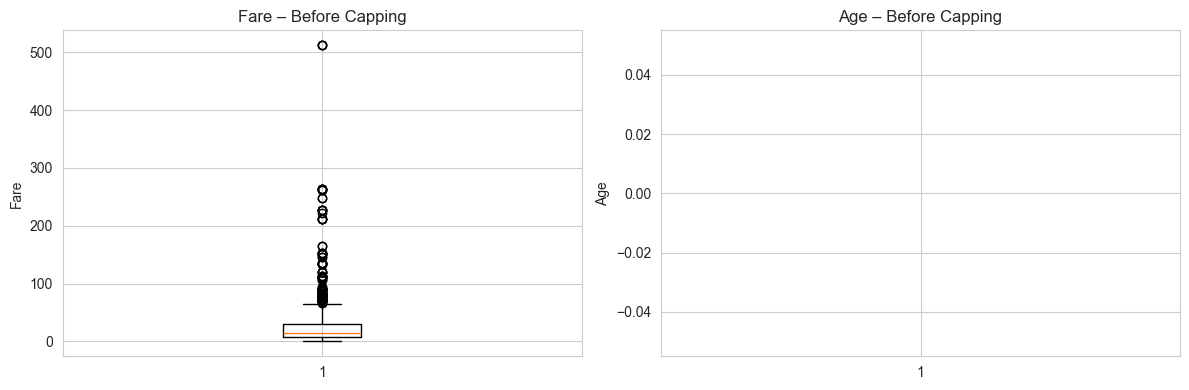

Fare stats: count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].boxplot(df['Fare'])
axes[0].set_title('Fare – Before Capping')
axes[0].set_ylabel('Fare')

axes[1].boxplot(df['Age'])
axes[1].set_title('Age – Before Capping')
axes[1].set_ylabel('Age')

plt.tight_layout()
plt.savefig('../notebooks/outlier_boxplots.png', dpi=80)
plt.show()
print("Fare stats:", df['Fare'].describe())


In [20]:
# Cap Fare at 99th percentile
fare_cap = df['Fare'].quantile(0.99)
df['Fare'] = df['Fare'].clip(upper=fare_cap)
print(f"Fare capped at 99th percentile: {fare_cap:.2f}")

# Cap Age at 99th percentile
age_cap = df['Age'].quantile(0.99)
df['Age'] = df['Age'].clip(upper=age_cap)
print(f"Age capped at 99th percentile: {age_cap:.2f}")


Fare capped at 99th percentile: 249.01
Age capped at 99th percentile: 65.87


### 1.4 Data Consistency

In [21]:
# Check Sex values
print("Sex unique values:", df['Sex'].unique())

# Standardize to lowercase
df['Sex'] = df['Sex'].str.lower().str.strip()

# Remove duplicates
before = len(df)
df.drop_duplicates(inplace=True)
print(f"Duplicates removed: {before - len(df)}")

print("\nFinal cleaned shape:", df.shape)


Sex unique values: <StringArray>
['male', 'female']
Length: 2, dtype: str
Duplicates removed: 0

Final cleaned shape: (891, 11)


In [22]:
# Save cleaned dataset
df.to_csv("../data/train_cleaned.csv", index=False)
print("Saved: train_cleaned.csv")


Saved: train_cleaned.csv


---
## Part 2: Feature Engineering

In [23]:
df = pd.read_csv("../data/train_cleaned.csv")
print("Shape:", df.shape)


Shape: (891, 11)


### 2.1 Family Features

In [24]:
# FamilySize: total people in the group including the passenger
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

# IsAlone: 1 if no family on board
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

print("FamilySize distribution:")
print(df['FamilySize'].value_counts().sort_index())
print("\nIsAlone counts:", df['IsAlone'].value_counts().to_dict())


FamilySize distribution:
FamilySize
1     537
2     161
3     102
4      29
5      15
6      22
7      12
8       6
11      7
Name: count, dtype: int64

IsAlone counts: {1: 537, 0: 354}


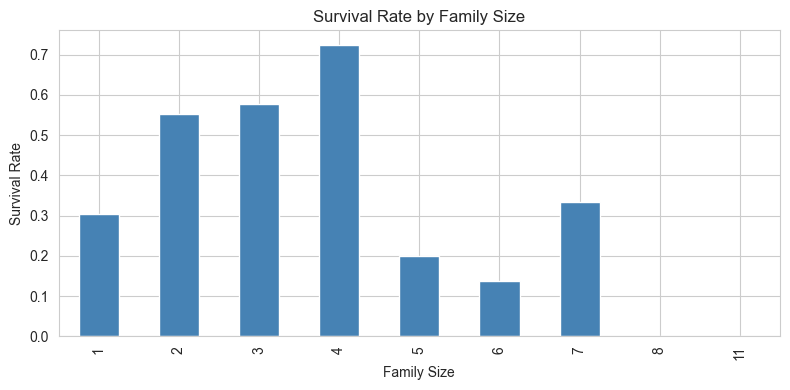

In [25]:
# Visualize survival by FamilySize
survival_by_family = df.groupby('FamilySize')['Survived'].mean()
survival_by_family.plot(kind='bar', figsize=(8, 4), color='steelblue')
plt.title('Survival Rate by Family Size')
plt.xlabel('Family Size')
plt.ylabel('Survival Rate')
plt.tight_layout()
plt.savefig('../notebooks/survival_familysize.png', dpi=80)
plt.show()


### 2.2 Title Extraction from Name

In [26]:
# Extract title from the Name column using regex
df['Title'] = df['Name'].str.extract(r',\s*([^\.]+)\.', expand=False).str.strip()

print("Titles found:", df['Title'].value_counts().to_dict())


Titles found: {'Mr': 517, 'Miss': 182, 'Mrs': 125, 'Master': 40, 'Dr': 7, 'Rev': 6, 'Major': 2, 'Mlle': 2, 'Col': 2, 'Don': 1, 'Mme': 1, 'Ms': 1, 'Lady': 1, 'Sir': 1, 'Capt': 1, 'the Countess': 1, 'Jonkheer': 1}


In [27]:
# Group rare titles into 'Other'
common_titles = ['Mr', 'Miss', 'Mrs', 'Master']
df['Title'] = df['Title'].apply(lambda x: x if x in common_titles else 'Other')

print("Title distribution after grouping:")
print(df['Title'].value_counts())


Title distribution after grouping:
Title
Mr        517
Miss      182
Mrs       125
Master     40
Other      27
Name: count, dtype: int64


### 2.3 Age Groups

In [28]:
bins = [0, 12, 17, 60, 100]
labels = ['Child', 'Teen', 'Adult', 'Senior']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)

print("AgeGroup distribution:")
print(df['AgeGroup'].value_counts())


AgeGroup distribution:
AgeGroup
Adult     579
Child      69
Teen       44
Senior     22
Name: count, dtype: int64


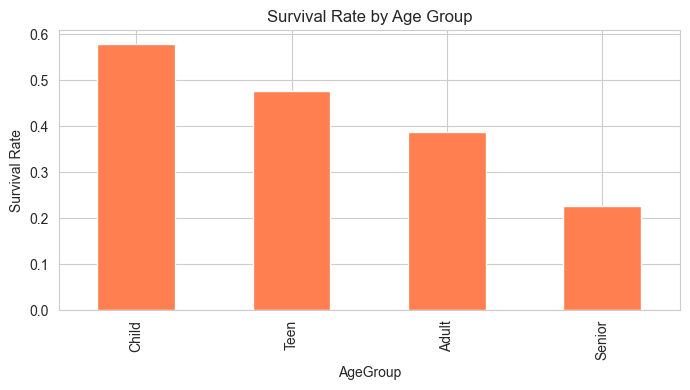

In [29]:
# Survival rate by age group
survival_by_age = df.groupby('AgeGroup')['Survived'].mean()
survival_by_age.plot(kind='bar', figsize=(7, 4), color='coral')
plt.title('Survival Rate by Age Group')
plt.ylabel('Survival Rate')
plt.tight_layout()
plt.savefig('../notebooks/survival_agegroup.png', dpi=80)
plt.show()


### 2.4 Fare Per Person

In [30]:
df['FarePerPerson'] = df['Fare'] / df['FamilySize']
print("FarePerPerson — first 5 rows:")
print(df[['Fare', 'FamilySize', 'FarePerPerson']].head())


FarePerPerson — first 5 rows:
      Fare  FamilySize  FarePerPerson
0   7.2500           2        3.62500
1  71.2833           2       35.64165
2   7.9250           1        7.92500
3  53.1000           2       26.55000
4   8.0500           1        8.05000


### 2.5 Feature Transformations (Log & Encoding)

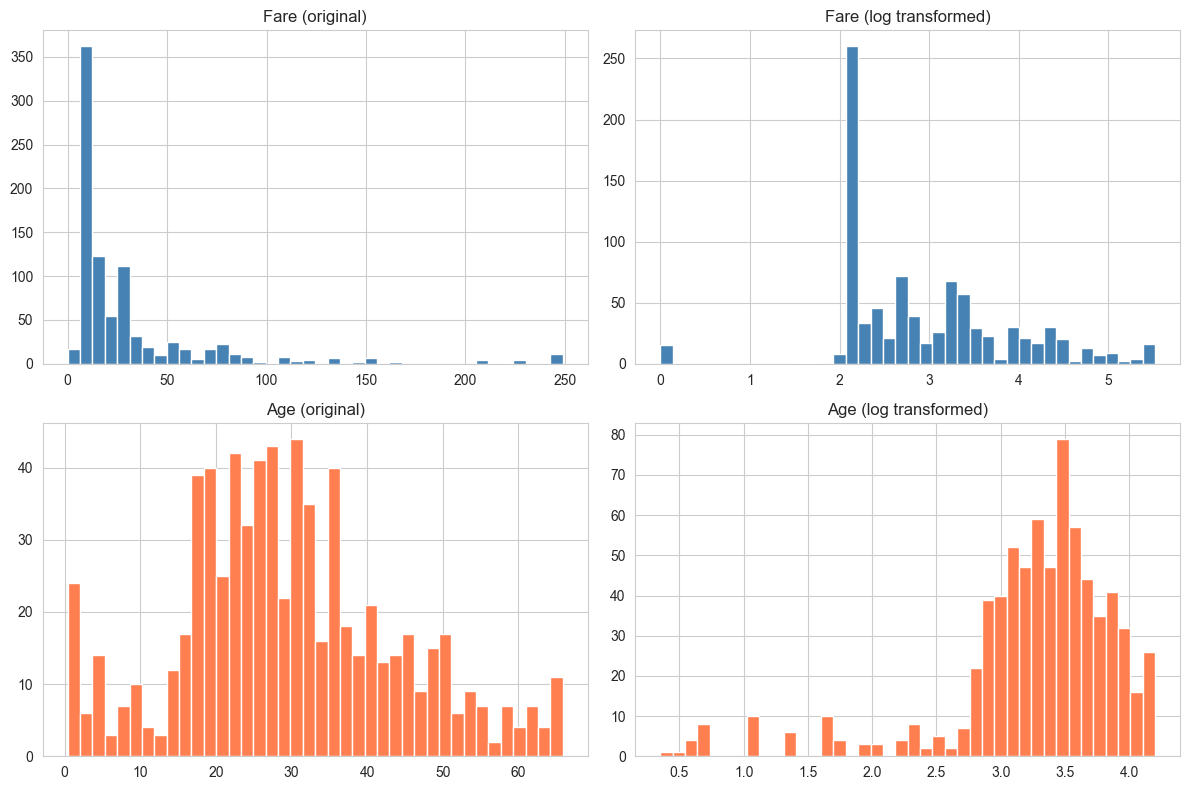

Log transform reduces skewness and makes distribution more normal


In [31]:
# Log transform skewed features
df['Fare_log'] = np.log1p(df['Fare'])
df['Age_log'] = np.log1p(df['Age'])

# Plot to justify transformation
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

df['Fare'].hist(ax=axes[0, 0], bins=40, color='steelblue')
axes[0, 0].set_title('Fare (original)')

df['Fare_log'].hist(ax=axes[0, 1], bins=40, color='steelblue')
axes[0, 1].set_title('Fare (log transformed)')

df['Age'].hist(ax=axes[1, 0], bins=40, color='coral')
axes[1, 0].set_title('Age (original)')

df['Age_log'].hist(ax=axes[1, 1], bins=40, color='coral')
axes[1, 1].set_title('Age (log transformed)')

plt.tight_layout()
plt.savefig('../notebooks/log_transforms.png', dpi=80)
plt.show()
print("Log transform reduces skewness and makes distribution more normal")


### 2.6 Categorical Encoding

In [32]:
# One-hot encode nominal features
df = pd.get_dummies(df, columns=['Sex', 'Embarked', 'Title', 'AgeGroup'], drop_first=False)

# Drop columns not needed for modeling
df.drop(columns=['Name', 'Ticket', 'PassengerId'], inplace=True)

print("Shape after encoding:", df.shape)
print("\nAll columns:")
print(df.columns.tolist())


Shape after encoding: (891, 25)

All columns:
['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'IsAlone', 'FarePerPerson', 'Fare_log', 'Age_log', 'Sex_female', 'Sex_male', 'Embarked_C', 'Embarked_Q', 'Embarked_S', 'Title_Master', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Other', 'AgeGroup_Child', 'AgeGroup_Teen', 'AgeGroup_Adult', 'AgeGroup_Senior']


In [33]:
df.to_csv("../data/train_engineered.csv", index=False)
print("Saved: train_engineered.csv")


Saved: train_engineered.csv


---
## Part 3: Feature Selection

In [34]:
df = pd.read_csv("../data/train_engineered.csv")
print("Shape:", df.shape)


Shape: (891, 25)


### 3.1 Correlation Analysis

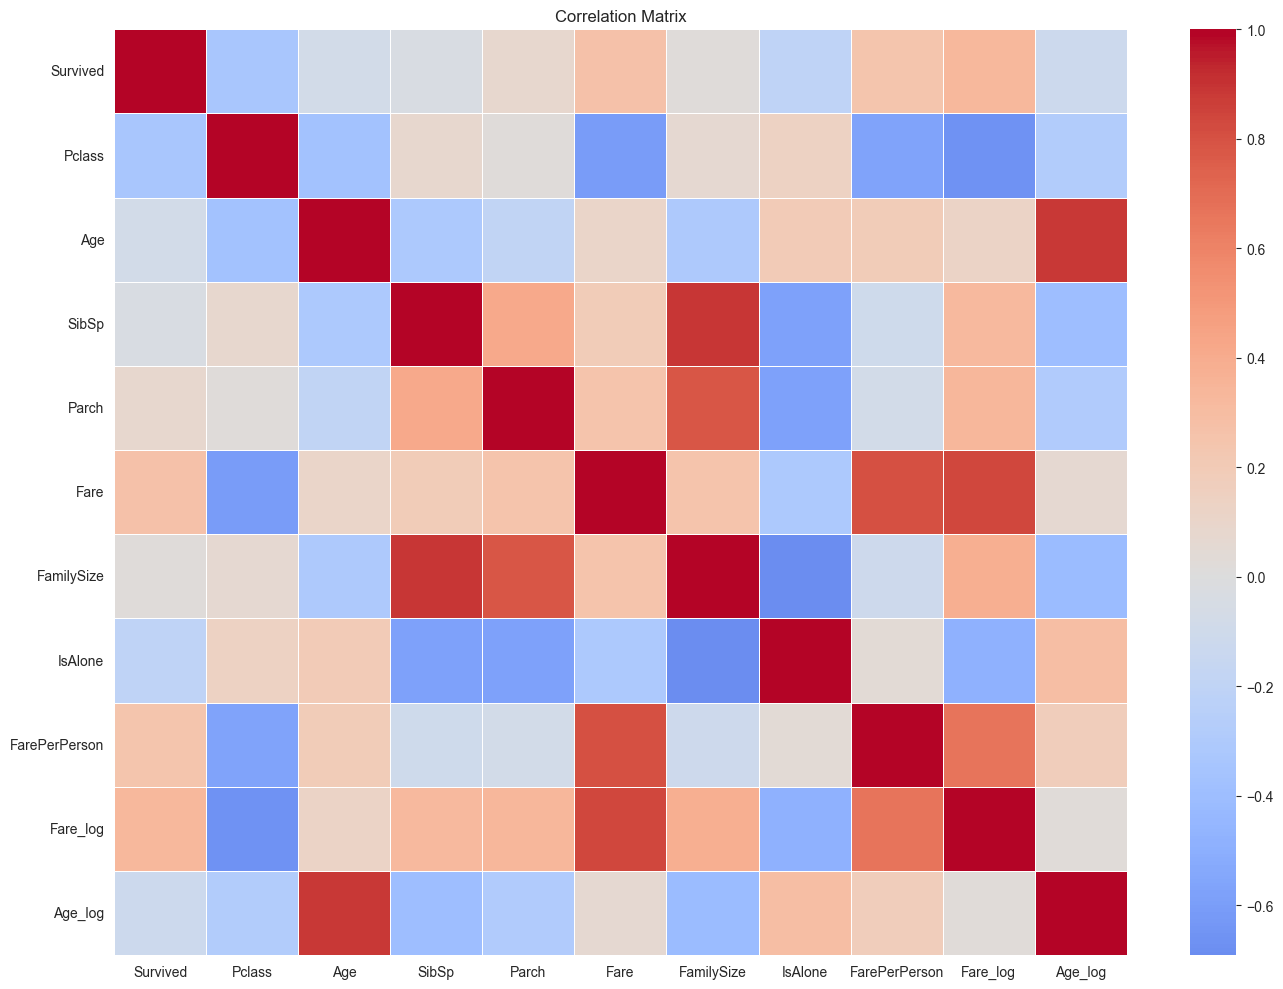

In [35]:
# Correlation heatmap (numeric features only)
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, annot=False, linewidths=0.5)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.savefig('../notebooks/correlation_heatmap.png', dpi=80)
plt.show()


In [36]:
# Find and drop highly correlated features (threshold > 0.95)
upper = corr_matrix.abs().where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr = [(col, row) for col in upper.columns for row in upper.index if upper.loc[row, col] > 0.95]
print("Highly correlated pairs (> 0.95):")
for pair in high_corr:
    print(f"  {pair[0]} <-> {pair[1]}: {corr_matrix.loc[pair[0], pair[1]]:.3f}")


Highly correlated pairs (> 0.95):


### 3.2 Feature Importance using Random Forest

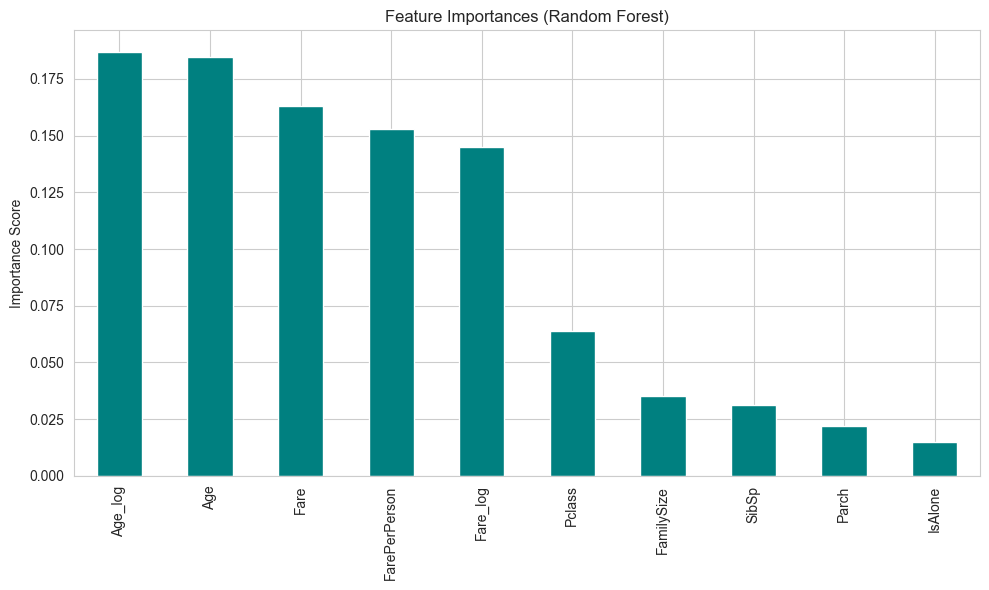

Top 10 features:
Age_log          0.187058
Age              0.184735
Fare             0.163169
FarePerPerson    0.153037
Fare_log         0.145009
Pclass           0.063794
FamilySize       0.035394
SibSp            0.031060
Parch            0.021948
IsAlone          0.014795
dtype: float64


In [37]:
X = df.drop(columns=['Survived']).select_dtypes(include=[np.number])
y = df['Survived']

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
importances.plot(kind='bar', color='teal')
plt.title('Feature Importances (Random Forest)')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.savefig('../notebooks/feature_importances.png', dpi=80)
plt.show()

print("Top 10 features:")
print(importances.head(10))


### 3.3 Feature Selection Justification

**Kept features** (importance > 0.01):
- `FarePerPerson`, `Fare_log`, `Fare` – Strong proxy for passenger class/wealth
- `Age`, `Age_log` – Age significantly affects survival (women & children first)
- `Pclass` – Ticket class is a direct survival indicator
- `FamilySize`, `SibSp`, `Parch` – Family group size affects evacuation chances
- `IsAlone` – Solo travellers had lower survival rate

**Dropped features** (importance < 0.01):
- One-hot encoded columns with very low variance contribution
- Redundant log-transformed columns if originals are already selected


In [38]:
# Select features above importance threshold
selected_features = importances[importances > 0.01].index.tolist()
selected_features.append('Survived')

df_selected = df[selected_features]
df_selected.to_csv("../data/train_selected.csv", index=False)

print(f"Selected {len(selected_features)-1} features for modeling:")
print(selected_features)
print("\nSaved: train_selected.csv")


Selected 10 features for modeling:
['Age_log', 'Age', 'Fare', 'FarePerPerson', 'Fare_log', 'Pclass', 'FamilySize', 'SibSp', 'Parch', 'IsAlone', 'Survived']

Saved: train_selected.csv


---
## Summary

- **Cleaned dataset** saved as `train_cleaned.csv`
- **Engineered features**: FamilySize, IsAlone, Title, AgeGroup, FarePerPerson, log transforms, one-hot encoding
- **Selected features** based on Random Forest importance saved as `train_selected.csv`
- All decisions documented inline above